In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data Loading

In [5]:
#loading the data
data = pd.read_csv("/kaggle/input/datasets/abedkhooli/arabic-100k-reviews/ar_reviews_100k.tsv", sep="\t")
print(data.head())

      label                                               text
0  Positive  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1  Positive  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2  Positive  هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3  Positive  خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4  Positive  ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


# Initial EDA

Printing Random data row:  Label | 'Text' 
Positive | '/ . كل شي.' 
random data lengths(chars) = 10
random data lengths(words) = 4
------------------------------------------------
average word length per text: 55.0260102601026
min word length per text: 1
max word length per text: 1663
Data count: 99999


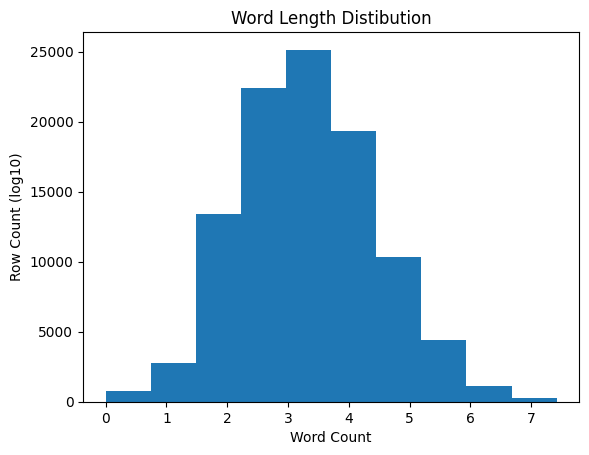

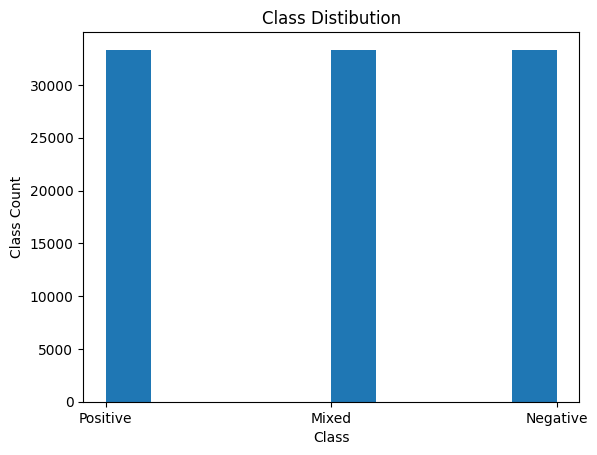

In [6]:
# Exploring/Understanding data properties (before preprocessing)

##defining common variables
sep = "------------------------------------------------"
data["text_word_length"] = data.text.apply( lambda x: len(x.split()) )

## printing randiom data 
#np.random.index(-1)  # set for reproducability
random_index = np.random.randint(len(data))
print("Printing Random data row:  Label | 'Text' ")
print(f"{data.label[random_index]} | '{data.text[random_index]}' ")
print(f"random data lengths(chars) = {len(data.text[random_index])}")
print(f"random data lengths(words) = {len((data.text[random_index]).split())}")


print(sep)
print(f"average word length per text: {data.text_word_length.sum()/len(data)}")
print(f"min word length per text: {data.text_word_length.min()}")
print(f"max word length per text: {data.text_word_length.max()}")
print(f"Data count: {len(data)}")


plt.hist(np.log(data["text_word_length"]))
plt.title("Word Length Distibution")
plt.ylabel("Row Count (log10)")
plt.xlabel("Word Count")
plt.show()

plt.hist(data["label"])
plt.title("Class Distibution")
plt.ylabel("Class Count")
plt.xlabel("Class")
plt.show()

# Data Preprocessing

In [7]:
import nltk
from nltk import word_tokenize, pos_tag, WordNetLemmatizer
from nltk.stem.isri import ISRIStemmer #using this instead of WordNetLemmatizer as we are doing arabic
from nltk.corpus import stopwords, wordnet
import string
import re

nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger_eng')

def preprocess_text(text):
    tokens =  word_tokenize(text)
    tokens = remove_stopwords(tokens,lang="arabic")
    tokens = remove_punctuation(tokens)
    #tokens = lemmantize_tokens(tokens) 
    tokens = stem_tokens(tokens)
    return tokens
        

def remove_stopwords(tokens, lang="english"):
    stopWords = stopwords.words(lang)
    return remove_from_list(tokens,stopWords)


def remove_punctuation(tokens):
    arabic_punct = "،؛؟"
    return [
        token for token in tokens
        if re.search(r'[\u0600-\u06FF]', token)
        and token not in string.punctuation
        and token not in arabic_punct
    ]
def remove_from_list(lst,to_remove):
     return [x for x in lst if x not in to_remove]

def lemmantize_tokens(tokens):
    tags = pos_tag(tokens)
    lemmatizer = WordNetLemmatizer()

    lem_tokens = []
    for word,tag in tags:
        lem_token = lemmatizer.lemmatize(word.lower(),get_pos(tag))
        lem_tokens.append(lem_token)
    return lem_tokens

def stem_tokens(tokens):
    stemmer = ISRIStemmer()
    return [stemmer.stem(word) for word in tokens]
    
def get_pos(tag):
    if tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("R"):
        return wordnet.ADV
    else: 
        return wordnet.NOUN


    
def preprocess_data(data):
    data.label = pd.Categorical(data.label).codes
    data.text = data.text.apply(preprocess_text)

preprocess_data(data)
print(data.head())

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


   label                                               text  text_word_length
0      2              [متز, نوع, نظف, وقع, جهز, شاطيء, طعم]                 9
1      2  [سبب, نجح, امر, شخص, دول, عشق, ترب, نحب, امر, ...                53
2      2  [هدف, وقي, نقل, صخب, شرع, قهر, الى, هدء, جبل, ...                48
3      2  [خلص, بدئ, الل, مست, بهر, زي, فيل, زرق, ميقراش...               107
4      2  [ياس, جلر, جزء, جزأ, دبي, ندق, كامل, خدم, ريح,...                15


In [8]:
data["clean_text"] = data["text"].apply(lambda lst: " ".join(lst))
print(data["clean_text"].head())

0                        متز نوع نظف وقع جهز شاطيء طعم
1    سبب نجح امر شخص دول عشق ترب نحب امر ومض فكر نص...
2    هدف وقي نقل صخب شرع قهر الى هدء جبل شيش عرف حق...
3    خلص بدئ الل مست بهر زي فيل زرق ميقراش احس حمد ...
4         ياس جلر جزء جزأ دبي ندق كامل خدم ريح نفس وجد
Name: clean_text, dtype: object


In [9]:
data.head()

,label,text,text_word_length,clean_text
0,2,"[متز, نوع, نظف, وقع, جهز, شاطيء, طعم]",9,متز نوع نظف وقع جهز شاطيء طعم
1,2,"[سبب, نجح, امر, شخص, دول, عشق, ترب, نحب, امر, ...",53,سبب نجح امر شخص دول عشق ترب نحب امر ومض فكر نص...
2,2,"[هدف, وقي, نقل, صخب, شرع, قهر, الى, هدء, جبل, ...",48,هدف وقي نقل صخب شرع قهر الى هدء جبل شيش عرف حق...
3,2,"[خلص, بدئ, الل, مست, بهر, زي, فيل, زرق, ميقراش...",107,خلص بدئ الل مست بهر زي فيل زرق ميقراش احس حمد ...
4,2,"[ياس, جلر, جزء, جزأ, دبي, ندق, كامل, خدم, ريح,...",15,ياس جلر جزء جزأ دبي ندق كامل خدم ريح نفس وجد


#EDA after preprocessing

In [10]:
from collections import Counter
from itertools import chain

all_tokens = list(chain.from_iterable(data.text))
word_counts = Counter(all_tokens)
print(word_counts.most_common(10))
print(word_counts.most_common()[-10:])

[('كتب', 78217), ('روي', 40338), ('جدا', 34135), ('ندق', 28372), ('ان', 26506), ('عمل', 24737), ('وجد', 24277), ('غرف', 22860), ('فى', 22412), ('حدث', 22167)]
[('كمالها،،،', 1), ('تصرفاتها،،', 1), ('جدلى', 1), ('بحياااتي', 1), ('عملاءلايقدر', 1), ('ظرت؟', 1), ('هالخربطة', 1), ('قعدلو', 1), ('قعش', 1), ('.مبتدىء', 1)]


# Feature extraction

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer(max_features=10000,min_df=5,max_df=0.95)
x = data.clean_text
y = data.label

x = cv.fit_transform(x).toarray()

print(f"x.shape: {x.shape}")
print(f"y.shape: {y.shape}")
print(f"sample x:\n {x[:5]}")
print(f"sample y:\n {y.head()}")

x.shape: (99999, 10000)
y.shape: (99999,)
sample x:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
sample y:
 0    2
1    2
2    2
3    2
4    2
Name: label, dtype: int8


In [12]:
import pickle

vectorizer_model_path = "/kaggle/working/arabic_vectorizer_model.pkl"

print("Saving TfidfVectorizer model...")
with open(vectorizer_model_path, 'wb') as file:
    # Use pickle.dump to serialize the model object and write it to the file
    pickle.dump(cv, file)
print(f"Done saving model to {vectorizer_model_path}")

Saving TfidfVectorizer model...
Done saving model to /kaggle/working/arabic_vectorizer_model.pkl


# train test split

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8)

# Model training/selection

In [14]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train, y_train)

MultinomialNB()

In [15]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.53      0.53      0.53      6634
           1       0.66      0.68      0.67      6644
           2       0.68      0.65      0.66      6722

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



In [16]:
import pickle

model_path = "/kaggle/working/arabic_classifier_model.pkl"

print("Saving model...")
with open(model_path, 'wb') as file:
    # Use pickle.dump to serialize the model object and write it to the file
    pickle.dump(model, file)
print(f"Done saving model to {model_path}")

Saving model...
Done saving model to /kaggle/working/arabic_classifier_model.pkl
